In [1]:
!mkdir -p /root/.kaggle
!cp "/content/drive/MyDrive/kaggle.json" /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d anthonytherrien/dog-vs-cat

Dataset URL: https://www.kaggle.com/datasets/anthonytherrien/dog-vs-cat
License(s): CC-BY-SA-4.0
100% 360M/360M [00:02<00:00, 154MB/s]



In [3]:
import zipfile


with zipfile.ZipFile('dog-vs-cat.zip','r') as zip_ref:
  zip_ref.extractall('/content')

In [4]:
import tensorflow as tf

In [5]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/animals",validation_split=0.2,subset='training',seed=42,image_size=(128,128),batch_size=32)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


In [6]:
val_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/animals",validation_split=0.2,subset='validation',seed=42,image_size=(128,128),batch_size=32)

Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [8]:
from tensorflow.keras.layers import Rescaling


normalization_layer=Rescaling(1./255)


train_data=train_ds.map(lambda x,y:(normalization_layer(x),y))

val_data=val_ds.map(lambda x,y:(normalization_layer(x),y))


In [9]:
import matplotlib.pyplot as plt

In [10]:
class_names=train_ds.class_names
print(class_names)

['cat', 'dog']


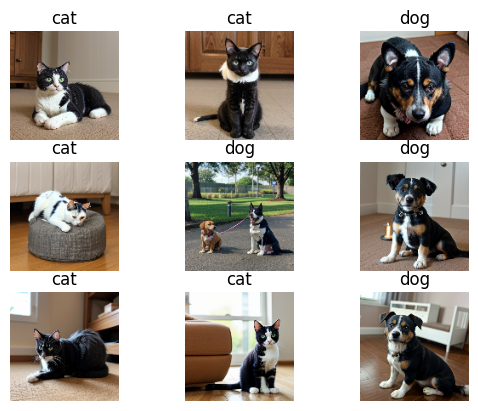

In [16]:
for images,labels in train_data.take(32):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.show()

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dropout,Dense



model=Sequential()


model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D())


model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))





/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
model.fit(train_data,validation_data=(val_data),verbose=1,epochs=10)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 263ms/step - accuracy: 0.5663 - loss: 0.7135 - val_accuracy: 0.7100 - val_loss: 0.6163
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step - accuracy: 0.7788 - loss: 0.4961 - val_accuracy: 0.8050 - val_loss: 0.4532
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 0.8612 - loss: 0.3496 - val_accuracy: 0.8350 - val_loss: 0.3814
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 0.9162 - loss: 0.2324 - val_accuracy: 0.8750 - val_loss: 0.3375
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step - accuracy: 0.9337 - loss: 0.1811 - val_accuracy: 0.9200 - val_loss: 0.2219
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.9663 - loss: 0.1040 - val_accuracy: 0.9150 - val_loss: 0.2854
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.9688 - loss: 0.0898 - val_accuracy: 0.9650 - val_loss: 0.1273
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 238ms/step - accuracy: 0.9900 - loss: 0.0268 - val_accuracy:

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np

img=image.load_img('/content/animals/cat/00002-4122619875.png',target_size=(128,128))

img_array=image.img_to_array(img)
img_array=img_array/255.0
img_array=np.expand_dims(img_array,axis=0)


predictions=model.predict(img_array)


if predictions[0][0]>0.5:
  print("Dog")

else:
 print("Cat")



# [0]cat<0.5>dog[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Cat
